In [4]:
%load_ext autoreload
%autoreload 2

import cupy as cp
from utils.data_loader import ImagenetteDataLoader
from utils.model import Network

import warnings
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading the Data

In [5]:
train_loader = ImagenetteDataLoader(
    root_path="input/imagenette2",
    split="train",
    target_size=(224, 224)
)

x_train, y_train = train_loader.load_images(normalize=True)
x_train.shape, y_train.shape

((9469, 3, 224, 224), (9469, 10))

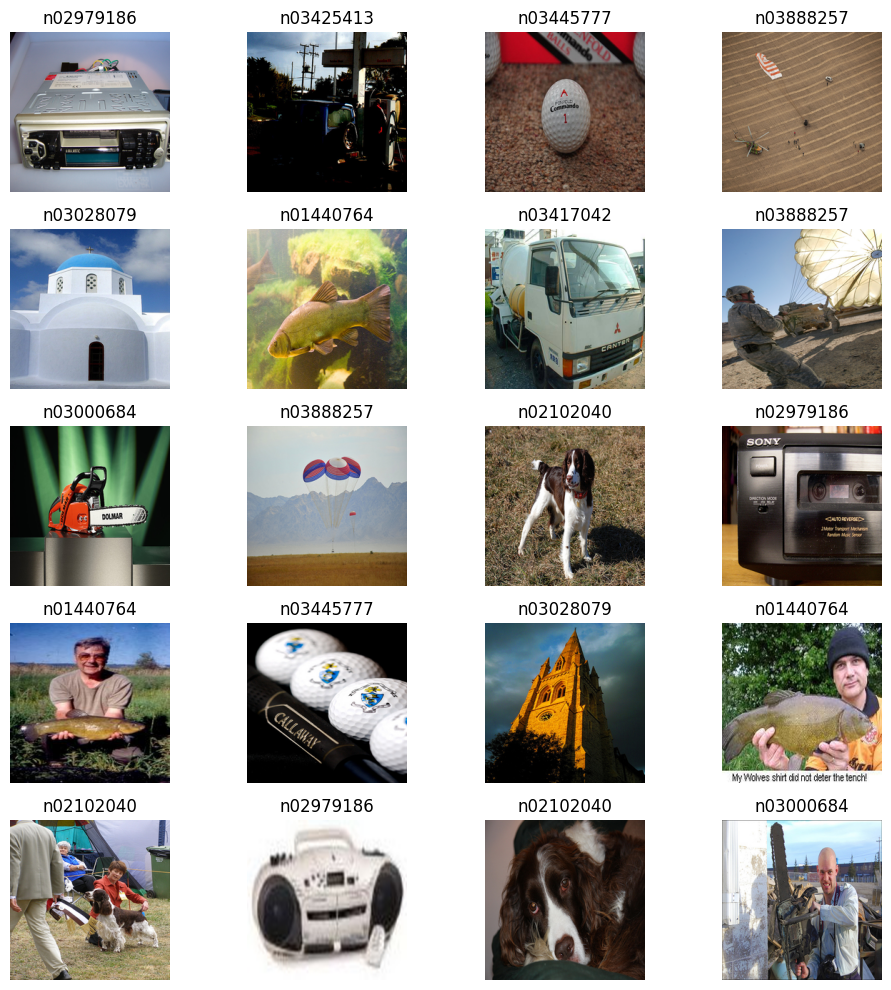

In [6]:
random_indices = cp.random.randint(0, len(x_train), size=20)
train_loader.plot_batch(random_indices.get().tolist(), figsize=(10, 10))

In [7]:
epochs = 1
filters = cp.random.random(size=(5, 3, 3, 3))

In [8]:
def run_filter(filter, x):
    _, f_height, f_width = filter.shape
    _, x_height, x_width = x.shape
    
    out_height = x_height - f_height + 1
    out_width = x_width - f_width + 1
    
    output = cp.zeros(shape=(out_height, out_width))
    
    for i in range(out_height):
        for j in range(out_width):
            output[i, j] = cp.sum(filter * x[:, i:i+f_height, j:j+f_width])
    
    return output

In [9]:
def conv_forward(x):
    filter_outputs = []
    
    for filter in filters:
        filter_outputs.append(run_filter(filter, x))

    return cp.array(filter_outputs)

In [ ]:
for epoch in range(epochs):
    for i in range(10):
        filter_outputs = conv_forward(x_train[i])
        print(filter_outputs.shape)

(5, 222, 222)
(5, 222, 222)
(5, 222, 222)
(5, 222, 222)
(5, 222, 222)
(5, 222, 222)
(5, 222, 222)
(5, 222, 222)
(5, 222, 222)
(5, 222, 222)


In [11]:
layer_definitions = [
    {"type": "ReLU", "input_size": 300, "num_neurons": 300},
    {"type": "ReLU", "input_size": 300, "num_neurons": 200},
    {"type": "ReLU", "input_size": 200, "num_neurons": 100},
    {"type": "ReLU", "input_size": 100, "num_neurons": 50},
    {"Sigmoid": "ReLU", "input_size": 20, "num_neurons": 1}
]

network = Network(layer_definitions=layer_definitions)

In [12]:
network.describe()

Network Architecture

Layer 1: ReluLayer
  Weights Shape: (300, 300) | Biases Shape: (300,)
  Parameters: 90,300

Layer 2: ReluLayer
  Weights Shape: (300, 200) | Biases Shape: (200,)
  Parameters: 60,200

Layer 3: ReluLayer
  Weights Shape: (200, 100) | Biases Shape: (100,)
  Parameters: 20,100

Layer 4: ReluLayer
  Weights Shape: (100, 50) | Biases Shape: (50,)
  Parameters: 5,050

Layer 5: Layer
  Weights Shape: (20, 1) | Biases Shape: (1,)
  Parameters: 21

Total Parameters: 175,671
